In [1]:
import pandas as pd
import gseapy as gp

res = pd.read_csv(
    "/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-output/d2_secretory_pcs_deseq2_results.csv",
    index_col=0
)


In [2]:
libs = gp.get_library_name()
for lib in libs:
    print(lib)

ARCHS4_Cell-lines
ARCHS4_IDG_Coexp
ARCHS4_Kinases_Coexp
ARCHS4_TFs_Coexp
ARCHS4_Tissues
Achilles_fitness_decrease
Achilles_fitness_increase
Aging_Perturbations_from_GEO_down
Aging_Perturbations_from_GEO_up
Allen_Brain_Atlas_10x_scRNA_2021
Allen_Brain_Atlas_down
Allen_Brain_Atlas_up
Azimuth_2023
Azimuth_Cell_Types_2021
BioCarta_2013
BioCarta_2015
BioCarta_2016
BioPlanet_2019
BioPlex_2017
CCLE_Proteomics_2020
CM4AI_U2OS_Protein_Localization_Assemblies
COMPARTMENTS_Curated_2025
COMPARTMENTS_Experimental_2025
CORUM
COVID-19_Related_Gene_Sets
COVID-19_Related_Gene_Sets_2021
Cancer_Cell_Line_Encyclopedia
CellMarker_2024
CellMarker_Augmented_2021
ChEA_2013
ChEA_2015
ChEA_2016
ChEA_2022
Chromosome_Location
Chromosome_Location_hg19
ClinVar_2019
ClinVar_2025
DGIdb_Drug_Targets_2024
DSigDB
Data_Acquisition_Method_Most_Popular_Genes
DepMap_CRISPR_GeneDependency_CellLines_2023
DepMap_WG_CRISPR_Screens_Broad_CellLines_2019
DepMap_WG_CRISPR_Screens_Sanger_CellLines_2019
Descartes_Cell_Types_and_Tissu

In [3]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
MIR1302-2HG,0.000000,NaN,NaN,NaN,NaN,NaN
AL627309.1,2.755916,-0.237487,1.113636,-0.213253,0.831129,NaN
AL627309.3,0.000000,NaN,NaN,NaN,NaN,NaN
AL627309.5,6.693687,1.216867,0.756059,1.609488,0.107510,NaN
LINC01409,60.056726,0.542421,0.290348,1.868177,0.061737,0.225266
...,...,...,...,...,...,...
FATE1,0.000000,NaN,NaN,NaN,NaN,NaN
ATP2B3,0.000000,NaN,NaN,NaN,NaN,NaN
HCFC1-AS1,0.000000,NaN,NaN,NaN,NaN,NaN
OPN1MW,0.000000,NaN,NaN,NaN,NaN,NaN


In [4]:
## Process the res into a df that gsea will accept

In [5]:


# Start from your DESeq2 results
res_clean = res.copy()

# Drop genes without a statistic or padj
res_clean = res_clean.dropna(subset=["stat", "log2FoldChange", "padj"])


In [6]:
# Use the Wald test statistic as the ranking score
res_clean["score"] = res_clean["stat"]


In [7]:
rnk = res_clean[["score"]].sort_values("score", ascending=False)


In [8]:
pre_res = gp.prerank(
    rnk=rnk,                          # genes in index, 1 col of scores
    gene_sets="GO_Biological_Process_2021",  # or KEGG, Reactome, etc.
    outdir="gsea_iscs",
    min_size=15,
    max_size=500,
    permutation_num=1000,
    seed=42,
)

KeyboardInterrupt: 

In [11]:
pre_res_hallmark = gp.prerank(
    rnk=rnk,
    gene_sets="MSigDB_Hallmark_2020",
    outdir="gsea_iscs_hallmark",
    min_size=10,
    max_size=500,
    permutation_num=1000,
    seed=42,
)


In [ ]:
hallmark_ifn_inflam = pre_res_hallmark.res2d[
    pre_res_hallmark.res2d["Term"].str.contains("INTERFERON|INFLAMMATORY", case=False)
]
hallmark_ifn_inflam


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
15,prerank,Interferon Alpha Response,-0.478277,-2.005966,0.0,0.0,0.0,42/95,26.02%,ISG20;LGALS3BP;IFIT2;IRF7;GBP2;LAMP3;CCRL2;IFI...
17,prerank,Inflammatory Response,-0.456496,-1.989233,0.0,0.0,0.0,43/120,16.21%,PLAUR;ADRM1;MET;CXCL8;IFNGR2;LIF;CD82;EMP3;SLC...
34,prerank,Interferon Gamma Response,-0.338705,-1.53317,0.006803,0.01153,0.222,62/168,24.06%,PIM1;PFKP;MVP;METTL7B;PNP;ISG20;UPP1;NFKBIA;CD...


In [ ]:
egfr_markers = [
    "FOS", "FOSB", "JUN", "JUNB", "JUND",
    "EGR1", "EGR2", "EGR3",
    "DUSP4", "DUSP6",
    "MYC",
    "CCND1", "MCL1",
    "AREG", "EREG", "HBEGF"
]

res.loc[res.index.intersection(egfr_markers)].sort_values("log2FoldChange")


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
EREG,152.202201,-3.030886,0.994856,-3.046557,2.314789e-03,2.401274e-02
AREG,1750.964201,-1.781958,0.539776,-3.301293,9.624021e-04,1.264961e-02
EGR3,16.633972,-0.926038,0.427439,-2.166478,3.027470e-02,1.419573e-01
HBEGF,186.155055,-0.865455,0.262401,-3.298210,9.730336e-04,1.272992e-02
DUSP4,2058.649969,-0.621786,0.142355,-4.367845,1.254782e-05,4.225735e-04
DUSP6,257.760774,-0.546907,0.198246,-2.758722,5.802780e-03,4.654457e-02
JUND,3986.131568,-0.527989,0.087913,-6.005820,1.903679e-09,2.881514e-07
JUNB,512.502486,-0.479315,0.115173,-4.161688,3.159043e-05,9.186124e-04
JUN,1462.606854,-0.445644,0.213604,-2.086312,3.695041e-02,1.619399e-01
MCL1,611.494962,-0.251751,0.115222,-2.184917,2.889497e-02,1.375512e-01


Term
False    47
True      3
Name: count, dtype: int64


/var/folders/h4/gmb18r416rs2h3sdc7knc0500000gn/T/ipykernel_31412/2288291605.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


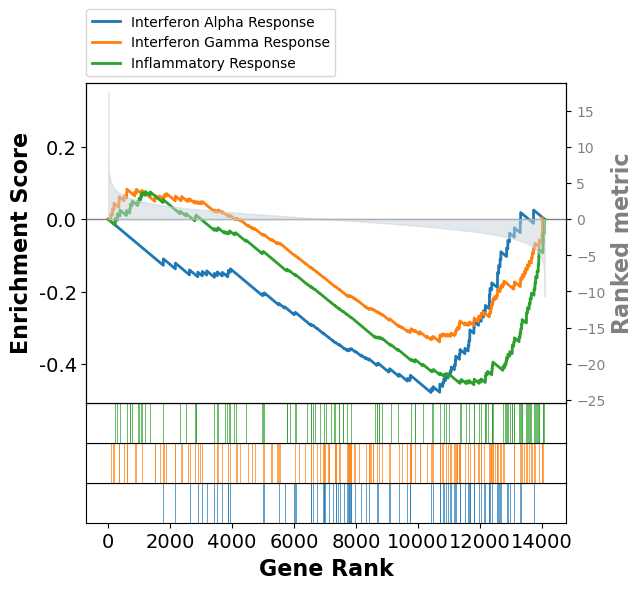

In [ ]:
import matplotlib.pyplot as plt

# Terms of interest (must match pre_res_hallmark.res2d["Term"])
terms_of_interest = [
    "Interferon Alpha Response",
    "Interferon Gamma Response",
    "Inflammatory Response",
]

# Quick check they exist
print(pre_res_hallmark.res2d["Term"].isin(terms_of_interest).value_counts())

# 1A. Built-in multi-panel GSEA plot
axs = pre_res_hallmark.plot(
    terms=terms_of_interest,
    show_ranking=True,          # show ranked genes underneath
    figsize=(6, 8),
    ofname=None                 # or "iscs_gsea_ifn_inflam.pdf"
)
plt.tight_layout()


In [ ]:
from gseapy.plot import barplot

barplot(
    hallmark_ifn_inflam,
    column="NES",                  # bar length
    title="Hallmark IFN / Inflammatory NES",
    color="salmon",
    ofname="gsea_barplot_ifn_inflam.pdf",
    figsize=(4, 4),
)


/var/folders/h4/gmb18r416rs2h3sdc7knc0500000gn/T/ipykernel_31412/657509725.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["neglogFDR"] = -np.log10(df["FDR q-val"].replace(0, 1e-300))


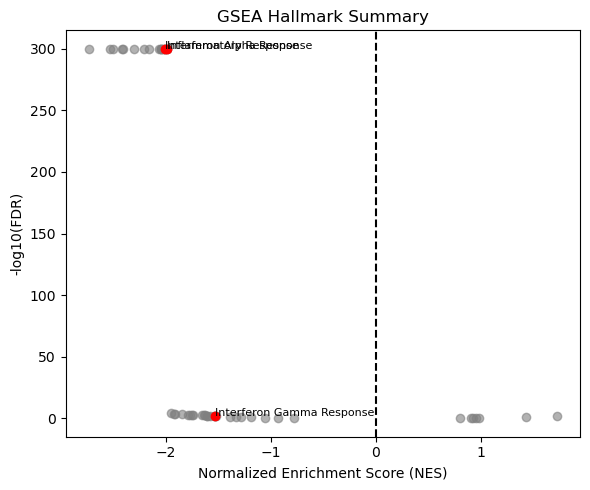

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df = pre_res_hallmark.res2d.copy()
df["neglogFDR"] = -np.log10(df["FDR q-val"].replace(0, 1e-300))

plt.figure(figsize=(6,5))
plt.scatter(df["NES"], df["neglogFDR"], alpha=0.6, color="grey")

# Highlight Inflammation/Interferon
mask = df["Term"].str.contains("INTERFERON|INFLAM", case=False)
plt.scatter(df.loc[mask,"NES"], df.loc[mask,"neglogFDR"], color="red")

for _, row in df[mask].iterrows():
    plt.text(row["NES"], row["neglogFDR"]+0.1, row["Term"], fontsize=8)

plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Normalized Enrichment Score (NES)")
plt.ylabel("-log10(FDR)")
plt.title("GSEA Hallmark Summary")
plt.tight_layout()
plt.savefig("gsea_summary_scatter.pdf", dpi=300)


/var/folders/h4/gmb18r416rs2h3sdc7knc0500000gn/T/ipykernel_31412/423144696.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["neglogFDR"] = -np.log10(df["FDR q-val"].replace(0, 1e-15))


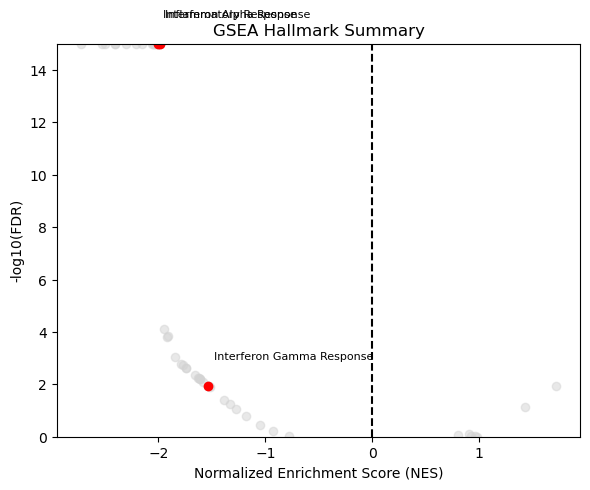

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df = pre_res_hallmark.res2d.copy()
df["neglogFDR"] = -np.log10(df["FDR q-val"].replace(0, 1e-15))

plt.figure(figsize=(6,5))
plt.scatter(df["NES"], df["neglogFDR"], alpha=0.5, color="lightgrey")

# Highlight inflammation/IFN pathways
mask = df["Term"].str.contains("INTERFERON|INFLAM", case=False)
plt.scatter(df.loc[mask,"NES"], df.loc[mask,"neglogFDR"], color="red")

# Add text labels only for the red ones
for _, row in df[mask].iterrows():
    plt.text(
        row["NES"] + 0.05,
        row["neglogFDR"] + 1,
        row["Term"],
        fontsize=8
    )

plt.axvline(0, color="black", linestyle="--")
plt.ylim(0, df["neglogFDR"].quantile(0.95))  # cap top at 95th percentile
plt.xlabel("Normalized Enrichment Score (NES)")
plt.ylabel("-log10(FDR)")
plt.title("GSEA Hallmark Summary")
plt.tight_layout()
plt.show()


[<Axes: xlabel='Gene Rank', ylabel='Ranked metric'>,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='Enrichment Score'>]

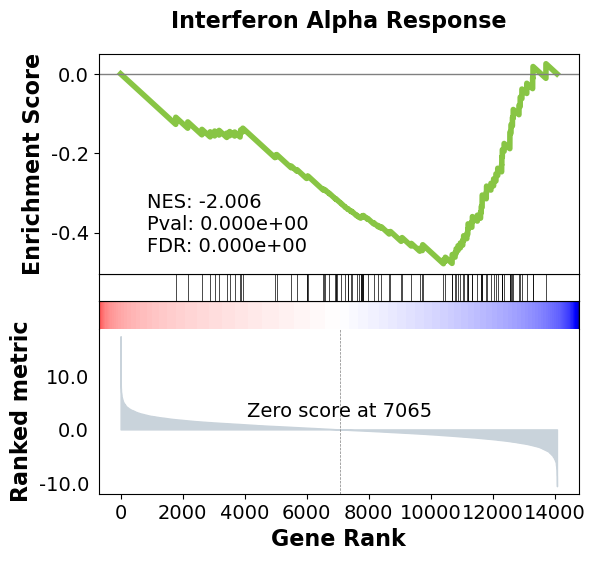

In [ ]:
from gseapy.plot import gseaplot

gseaplot(
    rank_metric=pre_res_hallmark.ranking,
    term="Interferon Alpha Response",
    **pre_res_hallmark.results["Interferon Alpha Response"],
)


In [ ]:
from gseapy.plot import heatmap

heatmap(
    pre_res_hallmark.res2d,
    z_score=True,
    figsize=(6,10),
    ofname="hallmark_heatmap.pdf"
)


ValueError: could not convert string to float: 'prerank'

### Let's take a look at more enteroendocrine gene sets

In [ ]:
import gseapy as gp

go_res = gp.prerank(
    rnk=rnk,                # your ranked gene list
    gene_sets="GO_Biological_Process_2021",
    outdir="gsea_go",
    min_size=10,
    max_size=5000,
    permutation_num=100
)


In [ ]:
import pandas as pd
lib = gp.get_library('GO_Biological_Process_2021')

# find relevant terms
endoderm_sets = [s for s in lib if "ENDODERM" in s.upper()]
eec_sets = [s for s in lib if "ENTERO" in s.upper()]
secretory_sets = [s for s in lib if "SECRETORY" in s.upper()]

endoderm_sets, eec_sets, secretory_sets


(['endoderm development (GO:0007492)',
  'endoderm formation (GO:0001706)',
  'endodermal cell differentiation (GO:0035987)',
  'endodermal cell fate commitment (GO:0001711)',
  'endodermal cell fate specification (GO:0001714)'],
 ['enteroendocrine cell differentiation (GO:0035883)'],
 ['constitutive secretory pathway (GO:0045054)',
  'negative regulation of regulated secretory pathway (GO:1903306)',
  'positive regulation of regulated secretory pathway (GO:1903307)',
  'regulation of regulated secretory pathway (GO:1903305)',
  'secretory granule organization (GO:0033363)'])

In [ ]:

# 1) Transcription factor target sets (TFT_Legacy)
tft_res = gp.prerank(
    rnk=rnk,
    gene_sets="TFT_Legacy",
    outdir=None,          # don't write files, just keep in memory
    min_size=10,
    max_size=5000,
    permutation_num=100,
    seed=42,
)

# 2) Reactome pathways as a second, more general check
reactome_res = gp.prerank(
    rnk=rnk,
    gene_sets="Reactome_2022",
    outdir=None,
    min_size=10,
    max_size=5000,
    permutation_num=100,
    seed=42,
)


2025-11-20 14:04:12,041 [ERROR] No supported gene_sets: TFT_Legacy


Exception: Error parsing gmt parameter for gene sets

In [ ]:
interferon_genes = [
    "IRF1", "STAT1", "STAT2",
    "ISG15", "IFI6", "IFI27",
    "IFIT1", "IFIT2", "IFIT3", 
    "OAS1", "OAS2", "OAS3", "OASL",
    "MX1", "MX2",
    "RSAD2", "ISG20",
    "CXCL9", "CXCL10", "CXCL11",
    "GBP1", "GBP2", "GBP4", "GBP5",
    "HERC5"
]


In [ ]:
res   # the DESeq2 output dataframe


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
MIR1302-2HG,0.000000,NaN,NaN,NaN,NaN,NaN
AL627309.1,2.755916,-0.237487,1.113636,-0.213253,0.831129,NaN
AL627309.3,0.000000,NaN,NaN,NaN,NaN,NaN
AL627309.5,6.693687,1.216867,0.756059,1.609488,0.107510,NaN
LINC01409,60.056726,0.542421,0.290348,1.868177,0.061737,0.225266
...,...,...,...,...,...,...
FATE1,0.000000,NaN,NaN,NaN,NaN,NaN
ATP2B3,0.000000,NaN,NaN,NaN,NaN,NaN
HCFC1-AS1,0.000000,NaN,NaN,NaN,NaN,NaN
OPN1MW,0.000000,NaN,NaN,NaN,NaN,NaN


In [ ]:
isg_results = (
    res.loc[res.index.intersection(interferon_genes)]
       .sort_values("log2FoldChange")
)

isg_results


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
CXCL10,37.140560,-2.729582,1.314651,-2.076278,0.037868,0.164986
CXCL11,116.443314,-1.247951,0.975821,-1.278873,0.200942,0.449707
ISG20,879.286318,-1.107686,0.283537,-3.906677,0.000094,0.002081
RSAD2,99.902070,-1.070536,0.466032,-2.297131,0.021611,0.113448
IFIT2,369.750055,-1.031170,0.345000,-2.988901,0.002800,0.027447
HERC5,124.077818,-0.804821,0.444692,-1.809838,0.070321,0.242922
OASL,93.090092,-0.789289,0.478315,-1.650144,0.098913,0.299635
OAS3,411.578830,-0.756443,0.360630,-2.097556,0.035944,0.159016
ISG15,748.112898,-0.732501,0.542639,-1.349885,0.177053,0.418740
MX1,992.528824,-0.710987,0.522074,-1.361850,0.173245,0.413631


In [ ]:
eec_markers = [
    "NEUROG3", "NEUROD1", "INSM1", "SOX4", "ATOH1",
    "CHGA", "CHGB", "SCG2", "SCG3", "PCSK1", "PCSK2",
    "GCG", "PYY", "GIP", "SST", "TAC1", "NTS", 
    "GAST", "CCK", "MLN", "INSL5", "UCN3"
]

res.loc[res.index.intersection(eec_markers)].sort_values("log2FoldChange")


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ATOH1,0.175426,-2.810027,4.456690,-0.630519,0.528355,NaN
CHGA,0.175426,-2.810027,4.456690,-0.630519,0.528355,NaN
GAST,0.089933,-0.962181,4.443132,-0.216555,0.828555,NaN
GIP,0.074089,-0.962181,4.443132,-0.216555,0.828555,NaN
SCG2,3.517428,-0.852188,1.133712,-0.751680,0.452244,NaN
CCK,127.598369,-0.769345,0.201781,-3.812763,0.000137,0.002782
CHGB,2.438996,-0.417861,1.674367,-0.249563,0.802925,NaN
SOX4,4964.168501,-0.169650,0.113896,-1.489512,0.136353,0.362363
SCG3,0.166879,-0.093639,4.343268,-0.021560,0.982799,NaN
UCN3,0.646697,-0.056292,2.487100,-0.022634,0.981943,NaN


In [9]:
reactome_res = gp.prerank(
    rnk=rnk,
    gene_sets="Reactome_2022",
    outdir=None,
    min_size=10,
    max_size=5000,
    permutation_num=100,
    seed=42,
)


In [10]:
# Look for EGFR/ERBB/EGF-related pathways in Reactome GSEA results
react_df = reactome_res.res2d.copy()

egfr_like = react_df["Term"].str.contains(
    "EGFR|ERBB|EPIDERMAL_GROWTH_FACTOR", case=False, na=False
)

react_df[egfr_like]  # inspect these rows to see the exact term names


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
208,prerank,SHC1 Events In EGFR Signaling R-HSA-180336,-0.647612,-1.73341,0.0,0.021601,0.93,7/11,13.75%,HRAS;AREG;HBEGF;EREG;GRB2;NRAS;SHC1
231,prerank,VEGFR2 Mediated Vascular Permeability R-HSA-52...,-0.559294,-1.694766,0.0,0.027959,0.94,8/22,10.63%,JUP;TRIB3;PKN1;CAV1;AKT1;PDPK1;CTNNA1;PRR5
240,prerank,GRB2 Events In EGFR Signaling R-HSA-179812,-0.634739,-1.683046,0.0,0.030883,0.98,6/10,13.32%,HRAS;AREG;HBEGF;EREG;GRB2;NRAS
301,prerank,Signaling By EGFR In Cancer R-HSA-1643713,-0.50395,-1.581556,0.0,0.060235,1.0,9/22,13.75%,UBC;HRAS;AREG;HBEGF;EREG;GRB2;CDC37;NRAS;SHC1
328,prerank,Constitutive Signaling By Overexpressed ERBB2 ...,-0.59325,-1.549346,0.041667,0.072478,1.0,5/10,13.75%,HRAS;GRB2;CDC37;NRAS;SHC1
363,prerank,Signaling By ERBB2 TMD/JMD Mutants R-HSA-9665686,-0.495387,-1.511001,0.037037,0.087598,1.0,8/18,13.75%,HRAS;HBEGF;EREG;GRB2;CDC37;ERBB3;NRAS;SHC1
393,prerank,Signaling By ERBB2 R-HSA-1227986,-0.409929,-1.471494,0.0,0.106185,1.0,16/44,13.92%,UBC;PTK6;HRAS;AKT1;HBEGF;EREG;GRB2;STUB1;CDC37...
481,prerank,VEGFR2 Mediated Cell Proliferation R-HSA-5218921,-0.484901,-1.378671,0.115385,0.164041,1.0,7/16,13.58%,ITPR3;HRAS;PDPK1;SRC;AHCYL1;NRAS;SPHK1
486,prerank,VEGFA-VEGFR2 Pathway R-HSA-4420097,-0.342835,-1.37361,0.065574,0.16805,1.0,23/76,17.75%,JUP;BCAR1;ITPR3;TRIB3;PKN1;HRAS;NCF2;CAV1;AKT1...
505,prerank,Downregulation Of ERBB2 Signaling R-HSA-8863795,-0.395782,-1.348345,0.086207,0.188579,1.0,8/24,13.54%,UBC;AKT1;HBEGF;EREG;STUB1;CDC37;ERBB3;RNF41


In [12]:
import matplotlib.pyplot as plt

# Pick key EGFR pathways (based on your react_df output)
egfr_terms = [
    "SHC1 Events in EGFR Signaling R-HSA-180336",
    "GRB2 Events in EGFR Signaling R-HSA-179812",
    "Constitutive Signaling By Overexpressed EGFR R-HSA-1227986",
]

# Check they exist
print(reactome_res.res2d["Term"].isin(egfr_terms).value_counts())

# Now plot them in the same multi-panel GSEA style
axs = reactome_res.plot(
    terms=egfr_terms,
    show_ranking=True,
    figsize=(6, 10),
    ofname="gsea_egfr_signaling.pdf"
)

plt.tight_layout()


Term
False    1260
Name: count, dtype: int64


KeyError: 'SHC1 Events in EGFR Signaling R-HSA-180336'

In [13]:
# Automatically pick the 3 strongest EGFR terms
egfr_terms = react_df.loc[egfr_like].sort_values("NES").head(3)["Term"].tolist()
egfr_terms


['SHC1 Events In EGFR Signaling R-HSA-180336',
 'VEGFR2 Mediated Vascular Permeability R-HSA-5218920',
 'GRB2 Events In EGFR Signaling R-HSA-179812']

In [14]:
axs = reactome_res.plot(
    terms=egfr_terms,
    show_ranking=True,
    figsize=(6, 10),
    ofname="gsea_egfr_signaling.pdf"
)

plt.tight_layout()




<Figure size 640x480 with 0 Axes>

In [15]:
import gseapy as gp

# Load GO Biological Process library
go_lib = gp.get_library("GO_Biological_Process_2021")

# Keyword search for endocrine lineage
keywords = ["ENDOCRINE", "ENTERO", "HORMONE", "SECRETORY", "ENDODERM"]

endocrine_terms = [
    term for term in go_lib 
    if any(k in term.upper() for k in keywords)
]

print("Found endocrine-related GO terms:")
for t in endocrine_terms:
    print("  -", t)

endocrine_terms


Found endocrine-related GO terms:
  - C21-steroid hormone biosynthetic process (GO:0006700)
  - C21-steroid hormone metabolic process (GO:0008207)
  - cellular response to growth hormone stimulus (GO:0071378)
  - cellular response to hormone stimulus (GO:0032870)
  - cellular response to peptide hormone stimulus (GO:0071375)
  - cellular response to steroid hormone stimulus (GO:0071383)
  - cellular response to thyroid hormone stimulus (GO:0097067)
  - constitutive secretory pathway (GO:0045054)
  - endocrine system development (GO:0035270)
  - endoderm development (GO:0007492)
  - endoderm formation (GO:0001706)
  - endodermal cell differentiation (GO:0035987)
  - endodermal cell fate commitment (GO:0001711)
  - endodermal cell fate specification (GO:0001714)
  - enteroendocrine cell differentiation (GO:0035883)
  - growth hormone receptor signaling pathway (GO:0060396)
  - growth hormone receptor signaling pathway via JAK-STAT (GO:0060397)
  - growth hormone secretion (GO:0030252)
  

['C21-steroid hormone biosynthetic process (GO:0006700)',
 'C21-steroid hormone metabolic process (GO:0008207)',
 'cellular response to growth hormone stimulus (GO:0071378)',
 'cellular response to hormone stimulus (GO:0032870)',
 'cellular response to peptide hormone stimulus (GO:0071375)',
 'cellular response to steroid hormone stimulus (GO:0071383)',
 'cellular response to thyroid hormone stimulus (GO:0097067)',
 'constitutive secretory pathway (GO:0045054)',
 'endocrine system development (GO:0035270)',
 'endoderm development (GO:0007492)',
 'endoderm formation (GO:0001706)',
 'endodermal cell differentiation (GO:0035987)',
 'endodermal cell fate commitment (GO:0001711)',
 'endodermal cell fate specification (GO:0001714)',
 'enteroendocrine cell differentiation (GO:0035883)',
 'growth hormone receptor signaling pathway (GO:0060396)',
 'growth hormone receptor signaling pathway via JAK-STAT (GO:0060397)',
 'growth hormone secretion (GO:0030252)',
 'hormone transport (GO:0009914)',
 

In [16]:
endocrine_terms = [
    "endoderm development (GO:0007492)",
    "endocrine system development (GO:0035270)",
    "endocrine cell differentiation (GO:0035838)",
    "hormone secretion (GO:0046879)",
    "regulated hormone secretion (GO:0046883)",
    "peptide hormone secretion (GO:0030072)",
    "positive regulation of hormone secretion (GO:0046887)",
    "growth hormone receptor signaling pathway via JAK-STAT (GO:0060397)",
]


In [18]:
# --- RUN GSEA prerank on GO terms ---
import gseapy as gp

# rnk must be your ranking dataframe (gene, score)
# assuming you already created rnk

go_res = gp.prerank(
    rnk=rnk,
    gene_sets="GO_Biological_Process_2021",
    outdir=None,        # keep results in memory
    min_size=10,
    max_size=5000,
    permutation_num=100,
    seed=42,
)

# Inspect available terms
print(go_res.res2d.head())


      Name                                               Term        ES  \
0  prerank              neutrophil degranulation (GO:0043312) -0.525754   
1  prerank  neutrophil activation involved in immune respo... -0.522855   
2  prerank          neutrophil mediated immunity (GO:0002446) -0.519736   
3  prerank            pyruvate metabolic process (GO:0006090) -0.717582   
4  prerank  tumor necrosis factor-mediated signaling pathw... -0.601705   

        NES NOM p-val FDR q-val FWER p-val    Tag %  Gene %  \
0 -2.619378       0.0       0.0        0.0  165/352  21.55%   
1  -2.61438       0.0       0.0        0.0  165/354  21.55%   
2  -2.60523       0.0       0.0        0.0  165/355  21.55%   
3 -2.572287       0.0       0.0        0.0    22/39  17.47%   
4 -2.466395       0.0       0.0        0.0    43/94  15.15%   

                                          Lead_genes  
0  PLAUR;ANXA2;TUBB;CTSD;RHOF;CAP1;JUP;PLAU;MVP;L...  
1  PLAUR;ANXA2;TUBB;CTSD;RHOF;CAP1;JUP;PLAU;MVP;L...  
2  PL

In [21]:
# Filter down to the chosen endocrine-related pathways
endo_df = go_res.res2d.copy()
endo_df = endo_df[endo_df["Term"].isin(endocrine_terms)]

display(endo_df)

# Use ONLY the terms that actually matched
terms_to_plot = endo_df["Term"].tolist()
print("Plotting terms:", terms_to_plot)



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
2883,prerank,peptide hormone secretion (GO:0030072),-0.288314,-0.722526,0.87037,0.928273,1.0,2/14,6.92%,GAL;CDK16


Plotting terms: ['peptide hormone secretion (GO:0030072)']


In [23]:
import matplotlib.pyplot as plt

axs = go_res.plot(
    terms=terms_to_plot,
    show_ranking=True,
    figsize=(6, 6 * len(terms_to_plot)),
    ofname="gsea_endocrine_subset.pdf",
)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>